# Author: Michael Chen (mwc2150@columbia.edu)

# 0. Introduction / Set-up

This notebook handles all data collection for my analysis on the fashion brand Everlane, which aims to answer the question: "Has Everlane's sustainability messaging become more concrete over time, or has it diverged from public perceptions of ethical practice?"

3 distinct sources were scraped to construct a multi-perspective corpus:
1. Reddit crawl: consumer sentiment collected via the PRAW API across five subreddits, filtered for relevance to Everlane as a brand
2. Everlane's website: brand-controlled content scraped via Selenium and BeautifulSoup across 12 sustainability and company pages, plus 19 individual factory subpages
3. News coverage: journalism pulled from GDELT's Global Knowledge Graph via BigQuery, with article text fetched using newspaper3k

The scraping choices here reflect a deliberate tradeoff: Reddit gives us unfiltered consumer opinions, the Everlane site gives us the brand's own narrative, and the news corpus gives us third-party mediation between the two. Each source has its own collection logic, data quality checks, and data integrity checks to avoid re-scraping.

The final outputs of this notebook: 3 raw CSV files in data/raw/ that feed directly into the analysis notebooks.
- reddit_posts.csv, 
- reddit_comments.csv, 
- everlane_web.csv, 
- and gdelt_articles_usable.csv

In [ ]:
# Install all required packages
import sys
!{sys.executable} -m pip install praw requests beautifulsoup4 selenium pandas undetected-chromedriver gdeltdoc newspaper3k lxml_html_clean

  Using cached praw-7.8.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached prawcore-2.4.0-py3-none-any.whl.metadata (5.0 kB)
  Using cached update_checker-0.18.0-py3-none-any.whl.metadata (2.3 kB)
Using cached praw-7.8.1-py3-none-any.whl (189 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.7 MB 2.9 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/9.7 MB 7.1 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/9.7 MB 8.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.7/9.7 MB 9.7 MB/s eta 0:00:01
   -------- ------------------------------- 2.0/9.7 MB 9.7 MB/s eta 0:00:01
   ---------- ----------------------------- 2.5/9.7 MB 9.4 MB/s eta 0:00:01
   ------------ --------------------------- 2.9/9.7 MB 9.2 MB/s eta 0:00:01
   --------------- ------------------------ 3.6/9.7 MB 10.6 MB/s eta 0:00:01
   ---------------- ----------------------- 4.1/9.7 MB 10.4 MB/s eta 0:00:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.3 requires langchain-core<2.0.0,>=1.2.19, but you have langchain-core 0.2.38 which is incompatible.
langchain-classic 1.0.3 requires langchain-text-splitters<2.0.0,>=1.1.1, but you have langchain-text-splitters 0.2.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Standard library
import logging
import os
import sys
import time
from datetime import date

# Data
import pandas as pd

# Reddit API
import praw

# Web scraping — requests + BeautifulSoup
import requests
from bs4 import BeautifulSoup

# Selenium + undetected-chromedriver
import selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
import undetected_chromedriver as uc

# News / GDELT
from gdeltdoc import GdeltDoc, Filters, near


# 1. Scraping data from Reddit view the official API (PRAW)
## Potential subreddits of interest, just from a quick and dirty search of "everlane" as a topic into Reddit
The idea is to cast a wide net on subreddits (post-level data) where I see mentions of Everlane and then pick out the top most active subreddits for analysis. This will serve as our public perception baseline, containing messy ground-level opinions that are easy to collect and are data-rich. 

a. Store related
- r/everlane
- r/everlaneclothing

b. Fashion sphere
- r/ethicalfashion
- r/SustainableFashion
- r/capsulewardrobe

c. Gendered fashion communities
- r/mensfashion
- r/womensfashion
- r/malefashionadvice
- r/femalefashionadvice

In [ ]:
logging.disable(logging.WARNING)

# Reddit client
reddit = praw.Reddit(
    client_id="fVxP3uTGv7IZtZs3jDIhwg",
    client_secret="3K_S1m8Q7sGM6k1ePwOq9AW8bpCR8Q",
    user_agent="everlane_analysis by u/Chocobae"
)

print(reddit.read_only)

True


In [ ]:
subreddits = [
    "Everlane", "everlaneclothing", "ethicalfashion", "femalefashionadvice",
    "SustainableFashion", "capsulewardrobe", "malefashionadvice"
]
rows = []

for sub_name in subreddits:
    subreddit = reddit.subreddit(sub_name)
    for post in subreddit.search("everlane", limit=200, sort="new"):
        rows.append({
            "source": "reddit",
            "subreddit": sub_name,
            "date": pd.to_datetime(post.created_utc, unit="s"),
            "title": post.title,
            "text": post.selftext,
            "score": post.score,
            "url": post.url
        })
df_reddit = pd.DataFrame(rows)
print(f"Total posts: {len(df_reddit)}")

# Count posts per subreddit
counts = df_reddit.groupby("subreddit").size().sort_values(ascending=False)
print(counts)

# # Drop any subreddit with fewer than 20 posts — not enough signal
# THRESHOLD = 20
# keep = counts[counts >= THRESHOLD].index.tolist()
# print(f"\nKeeping: {keep}")
# df_reddit = df_reddit[df_reddit["subreddit"].isin(keep)]
# print(f"Posts after filtering: {len(df_reddit)}")

Total posts: 580
subreddit
femalefashionadvice    200
malefashionadvice      200
capsulewardrobe         66
ethicalfashion          45
Everlane                35
SustainableFashion      31
everlaneclothing         3
dtype: int64


In [8]:
# Display subreddit size after scraping to contextualize the post counts
for sub_name in subreddits:
    sub = reddit.subreddit(sub_name)
    print(f"r/{sub_name}: {sub.subscribers:,} subscribers")

r/Everlane: 690 subscribers
r/everlaneclothing: 29 subscribers
r/ethicalfashion: 117,706 subscribers
r/femalefashionadvice: 5,810,964 subscribers
r/SustainableFashion: 91,088 subscribers
r/capsulewardrobe: 249,988 subscribers
r/malefashionadvice: 6,409,437 subscribers


## With just some preliminary EDA of our post-level data, we have a couple of interesting observations...
- Both gendered fashion advice subreddits yielded the most posts (hit our 200 post limit), which makes sense considering that the amount of subscribers in each forum is huge relative to the other subreddits
    - That being said, we could easily hit the 1000 cap on the PRAW API, but we will simply take 200 posts as a precaution to reduce any noise that may come from passing mentions of the store
- On the other hand, Everlane's reddit communities are on the nicher side, so their posts will be weighted more heavily as a direct signal to measure sentiments regarding the store's development over the past few years
- From my domain experience (being an amateur fashion enthusiast), Everlane is a brand whose primary consumer audience is women, so while I would like to choose r/malefashionadvice as part of the signal for analysis, I feel that we can extract the most valid opinions from r/femalefashionadvice
- r/capsulewardrobe also doesn't really make sense for this analysis as it seems like the topic of currating a lifetime wardrobe will be tangentially related to gathering inputs on Everlane as a brand  

In [9]:
# Final list of subreddits to keep based on post counts and relevance
# Maintain the store related subreddits, but drop the more general fashion ones that have fewer posts specifically about Everlane's clothing practices
keep = ["Everlane", "everlaneclothing", "ethicalfashion", "SustainableFashion", "femalefashionadvice"]
df_reddit = df_reddit[df_reddit["subreddit"].isin(keep)]
print(f"Posts after filtering: {len(df_reddit)}")
print(df_reddit.groupby("subreddit").size())

Posts after filtering: 314
subreddit
Everlane                35
SustainableFashion      31
ethicalfashion          45
everlaneclothing         3
femalefashionadvice    200
dtype: int64


In [10]:
# Save posts before making more API calls; data loading for integrity checks and to avoid having to re-scrape if we need to adjust the subreddit filtering
df_reddit.to_csv("../data/raw/reddit_posts.csv", index=False)
print("Posts saved.")

Posts saved.


Expanding the posts from our filtered dataframe, we can now take the most relevant comments for our analysis before moving onto the website scraper. This dataframe ends up being about 3x as large as our posts csv.

In [ ]:
comment_rows = []
skipped = 0
for i, row in df_reddit.iterrows():
    # Skip posts pointing to external URLs
    if "/comments/" not in row["url"]:
        skipped += 1
        continue
    # Extract the post ID from the URL
    post_id = row["url"].split("/comments/")[1].split("/")[0]
    submission = reddit.submission(id=post_id)
    # For now, top-level only, prevents conversational debates/off-topic threads from dominating the dataset
    # If set to 10, placeholder expansions might be too many API calls and we risk hitting rate limitss
    submission.comments.replace_more(limit=0)  
    
    for comment in submission.comments:
        comment_rows.append({
            "post_id": post_id,
            "subreddit": row["subreddit"],
            "date": pd.to_datetime(comment.created_utc, unit="s"),
            "text": comment.body,
            "score": comment.score
        })
    # Avoid rate limiting
    time.sleep(0.5)  

df_comments = pd.DataFrame(comment_rows)
print(f"Skipped {skipped} link posts")
print(f"Collected {len(df_comments)} comments")
df_comments.head()

Skipped 21 link posts
Collected 4429 comments


,post_id,subreddit,date,text,score
0,s5u3d9,Everlane,2023-09-08 19:04:00,How does it work?,2
1,s5u3d9,Everlane,2024-05-03 15:19:02,Awesome!! I’m excited to try it 😊 if you are l...,1
2,s3zy16,Everlane,2022-01-27 02:30:50,Have you received your order? I ordered my nor...,1
3,s3zy16,Everlane,2022-08-01 20:02:17,Bruh I just got some jeans that are wayyyy too...,1
4,s0ps4b,Everlane,2023-08-15 18:19:12,“leather” they use has to be fake. I own multi...,2


In [12]:
df_comments.to_csv("../data/raw/reddit_comments.csv", index=False)
print("Comments saved.")

Comments saved.


# 2. Scraping from Everlane's Website
## BeautifulSoup or Selenium?
I first ran the below check to see if Selenium is needed in the first place. If not, I could save time crawling for nav links with the standard \<a> HTML tags. Otherwise, the wait will be neccesary since the nav requires JavaScript to render certain links that are only accessible after JS events are triggered. 

In [ ]:
url = "https://www.everlane.com/pages/sustainability"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
soup = BeautifulSoup(response.text, "html.parser")

# Find all internal links on the page
links = [a["href"] for a in soup.find_all("a", href=True) if "everlane.com" in a["href"] or a["href"].startswith("/")]
print(links[:30])

['/collections/womens-new-arrivals', '/collections/womens-best-sellers', '/collections/womens-all-bundles', '/pages/womens', '/pages/mens', '/collections/mens-best-sellers', '/collections/mens-linen-clothing', '/collections/mens-chinos-khakis', '/collections/womens-new-arrivals', '/collections/womens-vacation-shop', '/collections/womens-dresses', '/collections/womens-linen-clothing', '/collections/spring-edit-luxury-of-comfort', '/collections/everlane-x-elena-bonvicini-denim-limited-edition', '/collections/womens-all-bundles', '/collections/everlane-shop-natural-fibers', '/collections/made-in-italy-footwear-collection', '/collections/now-trending-premium-sweaters', '/collections/womens-best-sellers', '/pages/cult-favorites-lookbook', '/collections/womens-all', '/collections/womens-tops', '/collections/womens-tees', '/collections/womens-dresses', '/collections/womens-jeans', '/collections/womens-pants-trousers', '/collections/womens-skirts-shorts', '/collections/womens-sweaters', '/coll

Bummer, it looks like we need to use Selenium after all. In the screenshot below, none of the links from the dropdown menu in the header were accessible; the BeautifulSoup crawl only included shopping links and missed all of the relevant pages we were looking for. I could hardcode the links in, but that would not be robust to future website updates, and not to mention, cumbersome to do. Also, what better oppurtunity is there to learn Selenium, right?

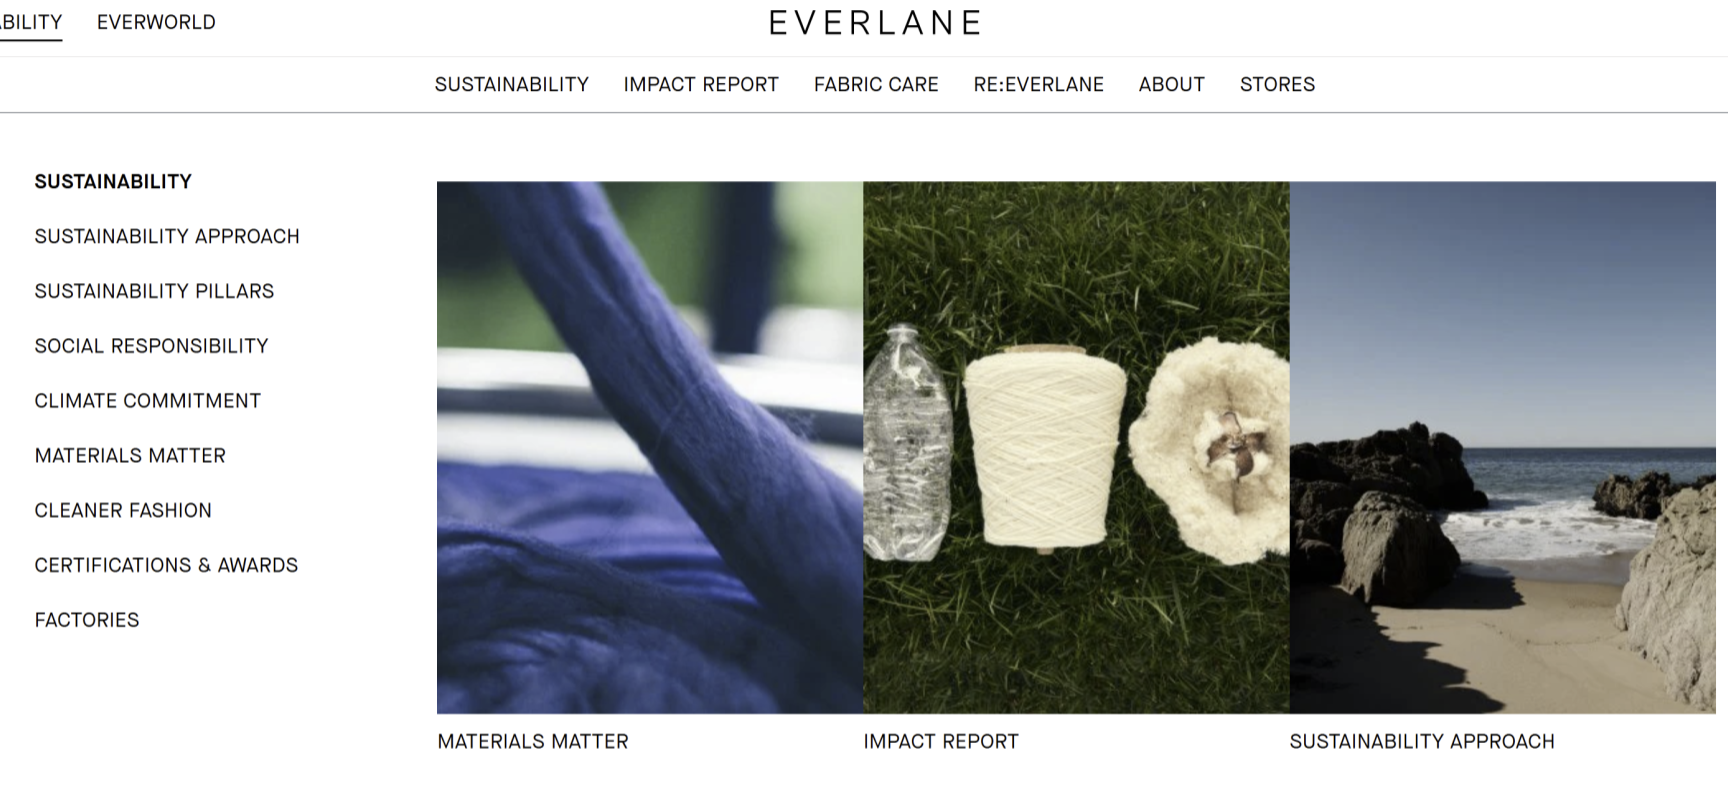

In [ ]:
options = uc.ChromeOptions()
# Using webdriver.Chrome: chrome options for headless browsing and to avoid issues in certain environments (like Docker or CI)
# Uncomment to run headlessly or if there's issues with sandboxing or shared memory
# options.add_argument("--headless")
# --no-sandbox and --disable-dev-shm-usage are Linux/Docker flags; on Windows they're a no-op
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")

# Initialize the uc to handle driver installation
driver = uc.Chrome(options=options)

# Navigate to the sustainability page and print the title to confirm it loaded correctly; Timed sleep to allow dynamic content to load
driver.get("https://www.everlane.com/pages/sustainability")
time.sleep(8)
print(driver.title)

'pip' is not recognized as an internal or external command,
operable program or batch file.


Everlane - Sustainability


In [52]:
# Testing the page source to confirm we got the full HTML content, not a bot-blocking page or an error message
# Also print the current URL to confirm we landed where we expected
driver.get("https://www.everlane.com/pages/sustainability")
time.sleep(8)
print(len(driver.page_source))
print(driver.page_source[:500])
print(driver.current_url)
if "just a moment" in driver.page_source.lower():
    raise RuntimeError("Cloudflare bot protection detected. Consider increasing the sleep time or using a different user agent.")
print(driver.title)

1294756
<html class="js" lang="en" style="--utility-bar-height: 32px; --mega-menu-height: 33px; --sticky-mega-menu-height: 33px; --announcement-bar-height: 32px; --header-height: 72px; --full-header-height: 104px; --sticky-header-height: 40px;" data-whatinput="initial" data-whatintent="initial"><head><style>
  @keyframes dgSlideIn {
    0% { opacity: 0; transform: scale(0.6); }
    50% { opacity: 1; transform: scale(1.02); }
    100% { opacity: 1; transform: scale(1); }
  }
  @keyframes dgSlideOut {
   
https://www.everlane.com/pages/sustainability
Everlane - Sustainability


That's sick, the sustainability page pops-up when toggled. Programatically, our page source has multi-million characters, fully JS-rendered HTML, and containes the correct URL. Selenium is working properly and we can now use BeautifulSoup as intended.

In [53]:
# 1. Define target page(s)
driver.get("https://www.everlane.com/pages/sustainability")
time.sleep(8)

# 2. Parse links with BeautifulSoup for the crawling step
# We want to find any other pages linked from the sustainability overview that might be relevant, even if we didn't identify them in our initial manual review
soup = BeautifulSoup(driver.page_source, "html.parser")
found_links = soup.find_all("a", href=True)
sustainability_urls = list(set([
    "https://www.everlane.com" + a["href"] if a["href"].startswith("/") else a["href"]
    for a in found_links
    if "/pages/" in a["href"] and "everlane.com" not in a["href"].split("/pages/")[0]
]))

print(f"Found {len(sustainability_urls)} pages:")
for url in sustainability_urls:
    print(url)

Found 28 pages:
https://www.everlane.com/pages/cleaner-fashion
https://www.everlane.com/pages/sustainability
https://www.everlane.com/pages/careers
https://www.everlane.com/pages/sustainability-pillars
https://www.everlane.com/pages/supply-chain
https://www.everlane.com/pages/redeem
https://www.everlane.com/pages/privacy
https://www.everlane.com/pages/the-cotton-care-guide
https://www.everlane.com/pages/affiliates
https://www.everlane.com/pages/vendor-code
https://www.everlane.com/pages/womens
https://www.everlane.com/pages/mens
https://www.everlane.com/pages/dei
https://www.everlane.com/pages/re-everlane-resell
https://www.everlane.com/pages/factories
https://www.everlane.com/pages/data-sharing-opt-out
https://www.everlane.com/pages/the-cashmere-care-guide
https://www.everlane.com/pages/social-responsibility
https://www.everlane.com/pages/sustainability-certifications
https://www.everlane.com/pages/the-denim-care-guide
https://www.everlane.com/pages/impact-report
https://www.everlane.

Of the 28 pages, the pages containing the keywords below appear to be the most relevant:


In [54]:
# 3. Filter keywords that signal sustainability-relevant pages
# Also included "about" to capture the current brand identity and mission statement
# These types of pages often contain sustainability-related language even if it's not dedicated to sustainability; again, it's more useful as a temporal baseline
keywords = ["sustain", "impact", "carbon", "factory", "factories", "supply", 
            "social", "dei", "cleaner", "preferred", "certif", "about"]

filtered_urls = [
    url for url in sustainability_urls
    if any(keyword in url.lower() for keyword in keywords)
]

print(f"Filtered to {len(filtered_urls)} relevant pages:")
for url in filtered_urls:
    print(url)

Filtered to 12 relevant pages:
https://www.everlane.com/pages/cleaner-fashion
https://www.everlane.com/pages/sustainability
https://www.everlane.com/pages/sustainability-pillars
https://www.everlane.com/pages/supply-chain
https://www.everlane.com/pages/dei
https://www.everlane.com/pages/factories
https://www.everlane.com/pages/social-responsibility
https://www.everlane.com/pages/sustainability-certifications
https://www.everlane.com/pages/impact-report
https://www.everlane.com/pages/about
https://www.everlane.com/pages/carbon
https://www.everlane.com/pages/preferred-materials


## The Actual Scraping Process
Using our pages that we found from Selenium x BeautifulSoup, we can now retrieve the store data of Everlane! 

In [55]:
web_rows = []

for url in filtered_urls:
    driver.get(url)
    time.sleep(8)

    if "just a moment" in driver.page_source.lower():
        print(f"SKIPPED (Cloudflare): {url}")
        continue

    soup = BeautifulSoup(driver.page_source, "html.parser")
    # 4. Extract all paragraph text
    paragraphs = soup.find_all("p")
    text = " ".join([p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True)])
    
    # 5. Extract page name from URL for labeling
    page_name = url.split("/pages/")[-1]
    
    web_rows.append({
        "source": "everlane_web",
        "page": page_name,
        "url": url,
        "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
        "text": text
    })
    print(f"{page_name}: {len(text)} characters")

# 6. Compile into DataFrame and save
df_web = pd.DataFrame(web_rows)
print(f"\nTotal: {len(df_web)} pages scraped")

cleaner-fashion: 4970 characters
sustainability: 3492 characters
sustainability-pillars: 5580 characters
supply-chain: 7549 characters
dei: 7973 characters
factories: 1068 characters
social-responsibility: 11780 characters
sustainability-certifications: 4398 characters
impact-report: 5956 characters
about: 2221 characters
carbon: 5404 characters
preferred-materials: 16140 characters

Total: 12 pages scraped


Note: Actually at this stage, pages started displaying 0 characters even though no Cloudflare skip messages printed.
- Root Cause: The driver did not actually load Everlane's pages to start with
    - driver.title prints "Just a moment...", which is Cloudflare's challenge HTML, not Everlane's actual content
    - headless Chrome is detected as a bot, so Cloudflare never actually resolved the challenge, resulting in empty 'found_links' and 'filtered_urls'
- Solution:
    - The time for rendering JS bumped up from 3s to 8s
    - Switch out webdriver.Chrome for undetected_chromedriver; this removes automation markers that Cloudflare detects from us

After these fixes, the above outputs had character counts that made sense :)

In [56]:
df_web.to_csv("../data/raw/everlane_web.csv", index=False)
print("Web pages saved.")

Web pages saved.


## Some preliminary thoughts...
- factories: 1068 characters seems suspiciously low and clicking on that page indeed leads to many subpages that are accessible only through clicking on the images
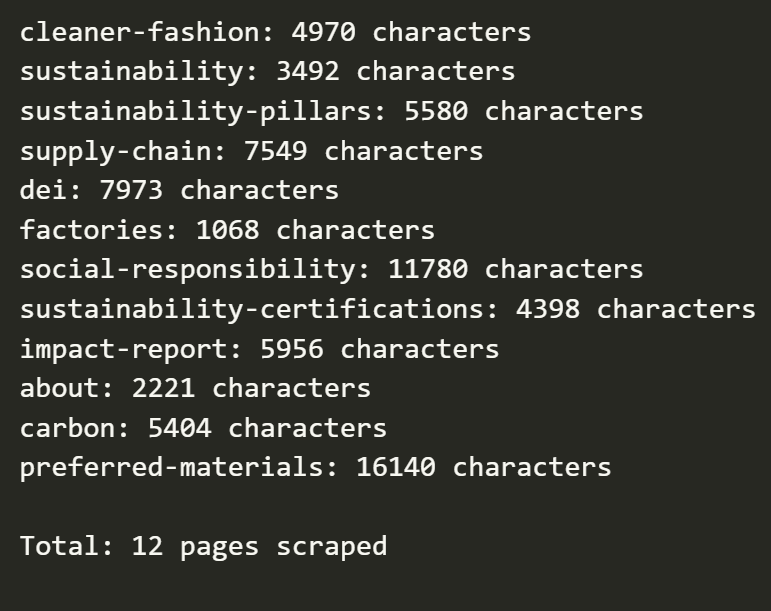
- To get a full picture of Everlane's follow-through, we still need this info, so I will expand on this and overwrite the factory info 

In [65]:
driver.get("https://www.everlane.com/pages/factories")
time.sleep(8)

# Scroll to load all cards
last_height = driver.execute_script("return document.body.scrollHeight")
while True:
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight)")
    time.sleep(3)
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == last_height:
        break
    last_height = new_height

# Find all hrefs pointing to factory subpages
anchors = driver.find_elements(By.CSS_SELECTOR, "a[href*='/pages/factories/']")
factory_urls = list(set([
    a.get_attribute("href") for a in anchors
]))

print(f"Found {len(factory_urls)} factory subpages:")
for url in sorted(factory_urls):
    print(url)

Found 19 factory subpages:
https://www.everlane.com/pages/factories/aqua-swim
https://www.everlane.com/pages/factories/brazil-shoes
https://www.everlane.com/pages/factories/cashmere
https://www.everlane.com/pages/factories/day-glove
https://www.everlane.com/pages/factories/day-sandal
https://www.everlane.com/pages/factories/denim-saitex
https://www.everlane.com/pages/factories/espadrille
https://www.everlane.com/pages/factories/forever-sneaker
https://www.everlane.com/pages/factories/form-sandal
https://www.everlane.com/pages/factories/golden-star-co-ltd
https://www.everlane.com/pages/factories/heel
https://www.everlane.com/pages/factories/jiangmen
https://www.everlane.com/pages/factories/pima-tees
https://www.everlane.com/pages/factories/rain-boot
https://www.everlane.com/pages/factories/silk
https://www.everlane.com/pages/factories/technical-outerwear
https://www.everlane.com/pages/factories/underwear
https://www.everlane.com/pages/factories/vietnam-knits
https://www.everlane.com/pag

In [66]:
factory_rows = []

for url in sorted(factory_urls):
    driver.get(url)
    time.sleep(8)
    
    elements = driver.find_elements(By.CSS_SELECTOR, "main h1, main h2, main h3, main h4, main p, main span, main li")
    seen = set()
    texts = []
    for el in elements:
        text = el.text.strip()
        if text and text not in seen and len(text) > 2:
            seen.add(text)
            texts.append(text)
    
    page_text = "\n".join(texts)
    slug = url.split("/pages/factories/")[-1]
    print(f"{slug}: {len(page_text)} characters")
    
    factory_rows.append({
        "source": "everlane_site",
        "url": url,
        "slug": f"factories/{slug}",
        "text": page_text
    })

aqua-swim: 2559 characters
brazil-shoes: 1150 characters
cashmere: 1744 characters
day-glove: 2461 characters
day-sandal: 1525 characters
denim-saitex: 2547 characters
espadrille: 1155 characters
forever-sneaker: 1816 characters
form-sandal: 1959 characters
golden-star-co-ltd: 1523 characters
heel: 1516 characters
jiangmen: 2090 characters
pima-tees: 2326 characters
rain-boot: 2811 characters
silk: 2292 characters
technical-outerwear: 2078 characters
underwear: 2997 characters
vietnam-knits: 1584 characters
yupoong-vietnam: 1962 characters


The above is promising, our factory Selenium scraper is actually parsing through all the images and corresponding locations/divisions of labour. That being said, it's worth looking at the structure of our everlane_web to get a grasp of where to write our new factory data to.

In [ ]:
# See what's in data/raw
print(os.listdir("../data/raw"))

# If everlane_web.csv exists, check its structure
df = pd.read_csv("../data/raw/everlane_web.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

['everlane_web.csv', 'reddit_comments.csv', 'reddit_posts.csv']
(12, 5)
['source', 'page', 'url', 'date', 'text']
         source                    page  \
0  everlane_web         cleaner-fashion   
1  everlane_web          sustainability   
2  everlane_web  sustainability-pillars   
3  everlane_web            supply-chain   
4  everlane_web                     dei   

                                                 url        date  \
0     https://www.everlane.com/pages/cleaner-fashion  2026-05-19   
1      https://www.everlane.com/pages/sustainability  2026-05-19   
2  https://www.everlane.com/pages/sustainability-...  2026-05-19   
3        https://www.everlane.com/pages/supply-chain  2026-05-19   
4                 https://www.everlane.com/pages/dei  2026-05-19   

                                                text  
0  $125.00away from free standard shipping You've...  
1  $125.00away from free standard shipping You've...  
2  $125.00away from free standard shipping You've... 

## Consolidated scrape?...
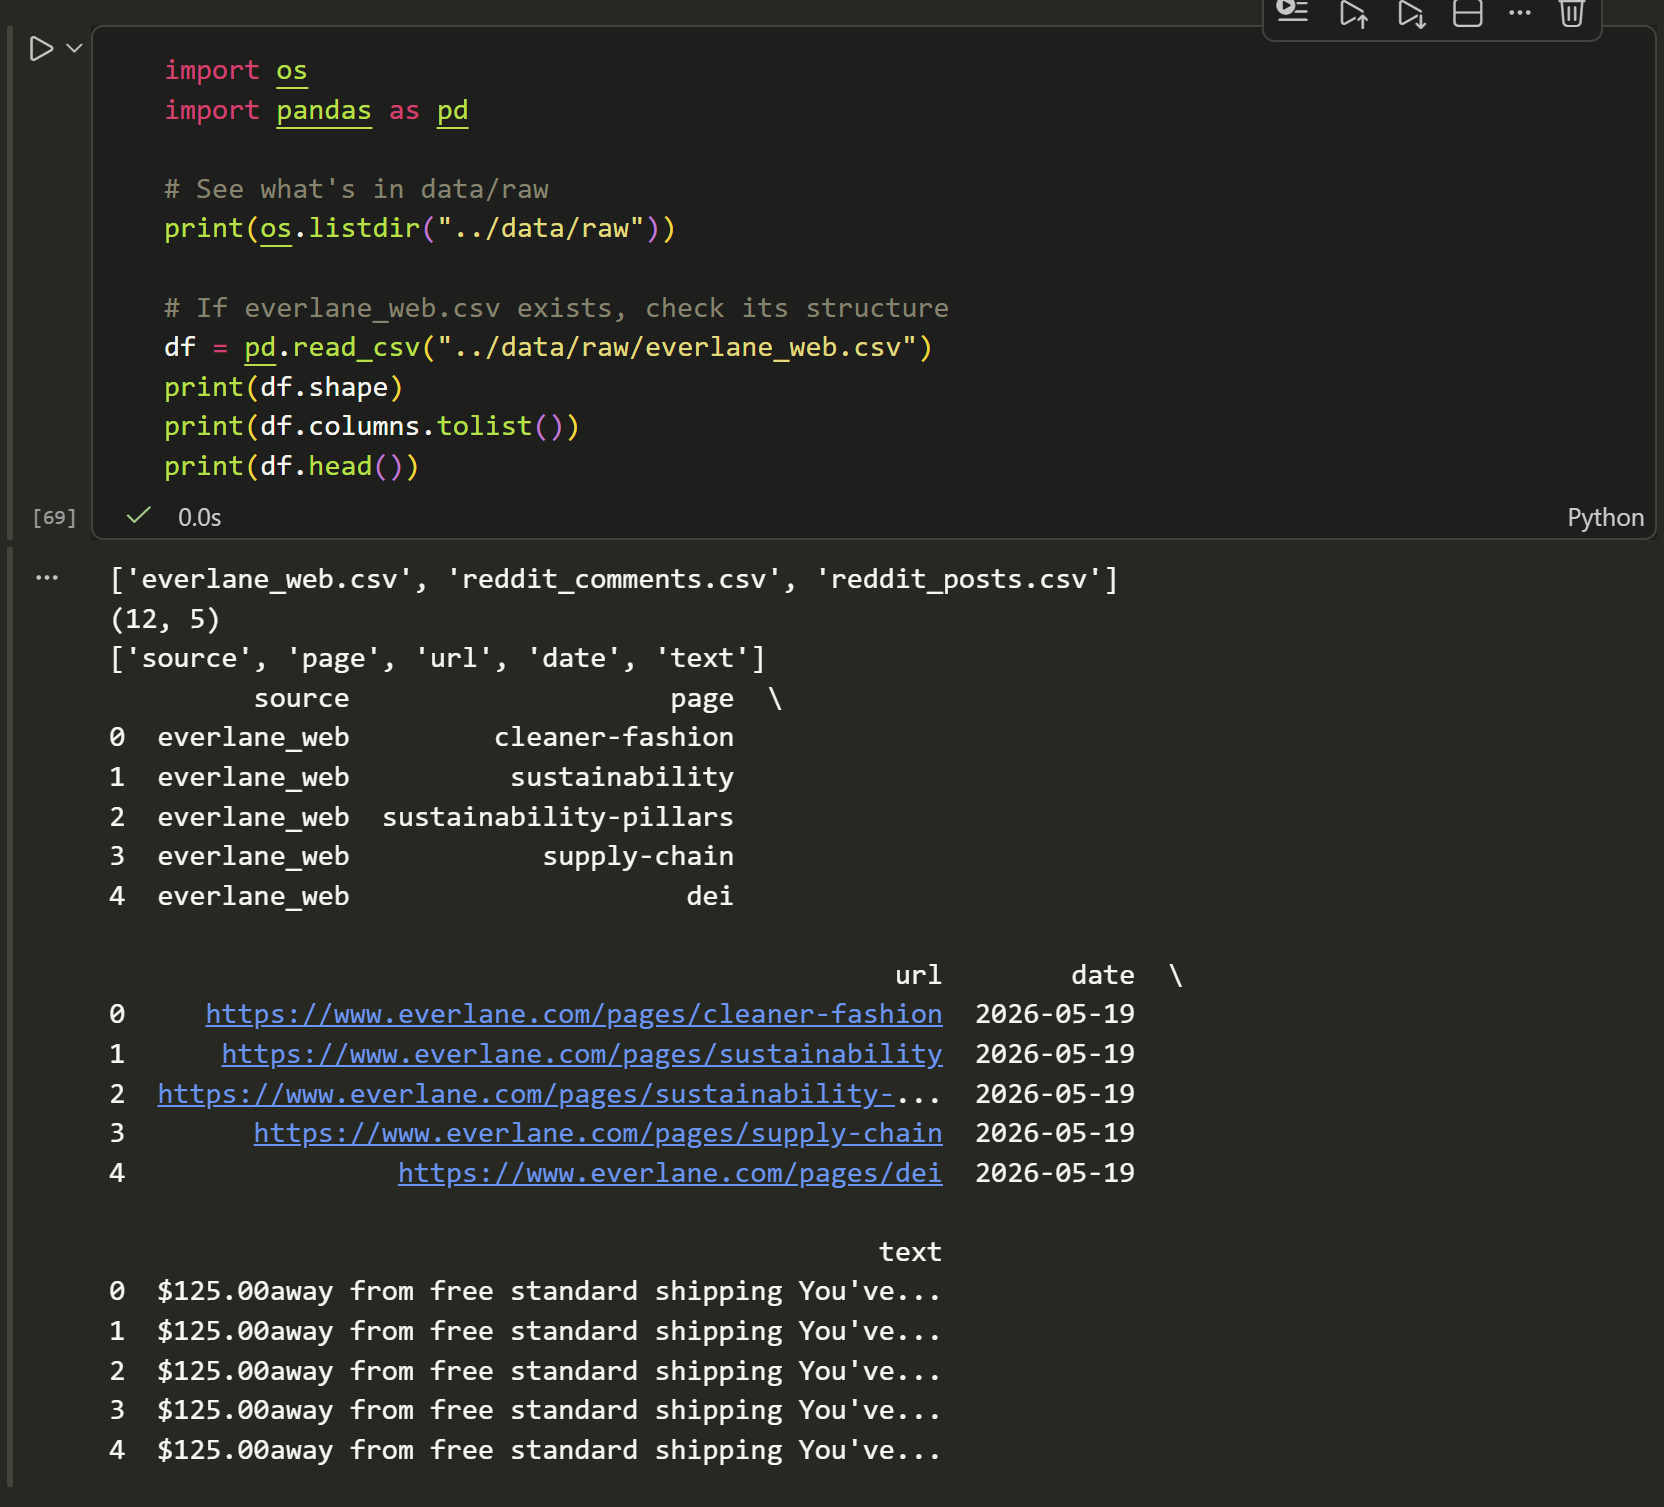
- Looking at the above, I fear we have to start at square 1 by re-scraping all pages with main-scoped selectors to strip nav/cart noise that we see above and add the 19 factory subpages
- Then after doing a full re-scraping, we can overwrite everlane_web.csv` with our clean output
 
While this is slightly tedious, it is good to have this here because it is pretty reusable for scraping future sites. 

In [ ]:
all_rows = []

# Original 12 pages
for url in filtered_urls:
    driver.get(url)
    time.sleep(8)
    
    elements = driver.find_elements(By.CSS_SELECTOR, "main h1, main h2, main h3, main h4, main p, main span, main li")
    seen = set()
    texts = []
    for el in elements:
        text = el.text.strip()
        if text and text not in seen and len(text) > 2:
            seen.add(text)
            texts.append(text)
    
    page_text = "\n".join(texts)
    slug = url.split("/pages/")[-1]
    print(f"{slug}: {len(page_text)} characters")
    
    all_rows.append({
        "source": "everlane_web",
        "page": slug,
        "url": url,
        "date": date.today().isoformat(),
        "text": page_text
    })

# 19 factory subpages
for url in sorted(factory_urls):
    driver.get(url)
    time.sleep(8)
    
    elements = driver.find_elements(By.CSS_SELECTOR, "main h1, main h2, main h3, main h4, main p, main span, main li")
    seen = set()
    texts = []
    for el in elements:
        text = el.text.strip()
        if text and text not in seen and len(text) > 2:
            seen.add(text)
            texts.append(text)
    
    page_text = "\n".join(texts)
    slug = "factories/" + url.split("/pages/factories/")[-1]
    print(f"{slug}: {len(page_text)} characters")
    
    all_rows.append({
        "source": "everlane_web",
        "page": slug,
        "url": url,
        "date": date.today().isoformat(),
        "text": page_text
    })

# Overwrite the CSV cleanly
df_web = pd.DataFrame(all_rows)
df_web.to_csv("../data/raw/everlane_web.csv", index=False)
print(f"\nSaved {len(df_web)} pages to everlane_web.csv")

cleaner-fashion: 4141 characters
sustainability: 2984 characters
sustainability-pillars: 7503 characters
supply-chain: 13007 characters
dei: 11586 characters
factories: 628 characters
social-responsibility: 15976 characters
sustainability-certifications: 4472 characters
impact-report: 3607 characters
about: 1778 characters
carbon: 7592 characters
preferred-materials: 15436 characters
factories/aqua-swim: 2559 characters
factories/brazil-shoes: 1150 characters
factories/cashmere: 1744 characters
factories/day-glove: 2461 characters
factories/day-sandal: 1525 characters
factories/denim-saitex: 2547 characters
factories/espadrille: 1155 characters
factories/forever-sneaker: 1816 characters
factories/form-sandal: 1959 characters
factories/golden-star-co-ltd: 1523 characters
factories/heel: 1516 characters
factories/jiangmen: 2090 characters
factories/pima-tees: 2326 characters
factories/rain-boot: 2811 characters
factories/silk: 2292 characters
factories/technical-outerwear: 2078 character

Awesome! All the data is now written properly to everlane_web.csv. Now onto the last step of our data collection.

# 3. Scraping for News Outlets

Similar to how Selenium and BS4 work together, I plan to use GDELT queries to return relevant article URLs on sentiments regardign Everlane, and newspaper3k to fetch the subsequent texts from these URLs. 

In [ ]:
# Connectivity warning only; root URL may time out on SSL handshake even when the actual query endpoints respond
# Demoted to a print so the loop still runs.
try:
    requests.get("https://api.gdeltproject.org", timeout=(5, 15))
    print("GDELT API reachable")
except Exception as _e:
    print(f"Warning: GDELT connectivity check failed ({type(_e).__name__}) — queries will attempt anyway.")

# Monkey-patch requests.get to enforce a 30s timeout; gdeltdoc does not expose one.
_orig_get = requests.get
requests.get = lambda *a, **kw: _orig_get(*a, **{"timeout": 30, **kw})

gd = GdeltDoc()

# "supply chain" / "fair trade" produce a 3-token near phrase (near15:"Everlane supply chain")
# that the GDELT API rejects. Replaced with single-token equivalents common in journalism.
queries = [
    ("Everlane", "sustainability", 15),
    ("Everlane", "transparency", 15),
    ("Everlane", "supply", 15),
    ("Everlane", "labor", 15),
    ("Everlane", "ethics", 15),

    ("Everlane", "greenwashing", 15),
    ("Everlane", "CSR", 15),
    ("Everlane", "fairtrade", 15),
    ("Everlane", "worker", 15),
    ("Everlane", "factory", 15),

    ("Everlane", "stakeholder", 15),
    ("Everlane", "accountability", 15),
]

all_articles = []

for q in queries:
    f = Filters(near=near(q[2], q[0], q[1]), start_date="2016-01-01", end_date="2026-05-15")

    try:
        results = gd.article_search(f)
        print(f"{q[1]}: {len(results)} articles")

        if len(results) >= 5:
            results["query_term"] = q[1]
            all_articles.append(results)

    except Exception as e:
        print(f"{q[1]}: failed — {e}")

    time.sleep(8)

# Restore original requests.get
requests.get = _orig_get


## Revised approach: single keyword search
After testing the 12-query "near" approach above, a few things stood out:
- near() silently drops articles that discuss both topics but not in adjacent sentences
- Terms like CSR or stakeholder is academic language I wanted to target that journalists would rarely use near a brand name; produced zero hits even when the API is working
- Having 12 queries x 8s sleep = 96s in sleeps alone, with heavy deduplication at the end is just not worth the time or the effort to rerun and debug

My thinking is that Everlane might just be niche enough that a single unrestricted search could capture all the relevant journalism about them-- sustainability coverage included. So we can shift gears and pull everything GDELT has on Everlane and flag topic relevance downstream during the analysis phase.

In [10]:
_orig_get = requests.get
requests.get = lambda *a, **kw: _orig_get(*a, **{"timeout": 30, **kw})

gd = GdeltDoc()
# GDELT article search only indexes ~3 months; drop start_date/end_date
f = Filters(keyword="Everlane", timespan="3m")

try:
    df_news = gd.article_search(f)
    print(f"Total articles: {len(df_news)}")
    df_news.to_csv("../data/raw/gdelt_news.csv", index=False)
    print("GDELT news articles saved.")
except Exception as e:
    import traceback
    print(f"Failed ({type(e).__name__}): {e}")
    traceback.print_exc()
finally:
    requests.get = _orig_get


Total articles: 98
GDELT news articles saved.


## Looking through the scrape...
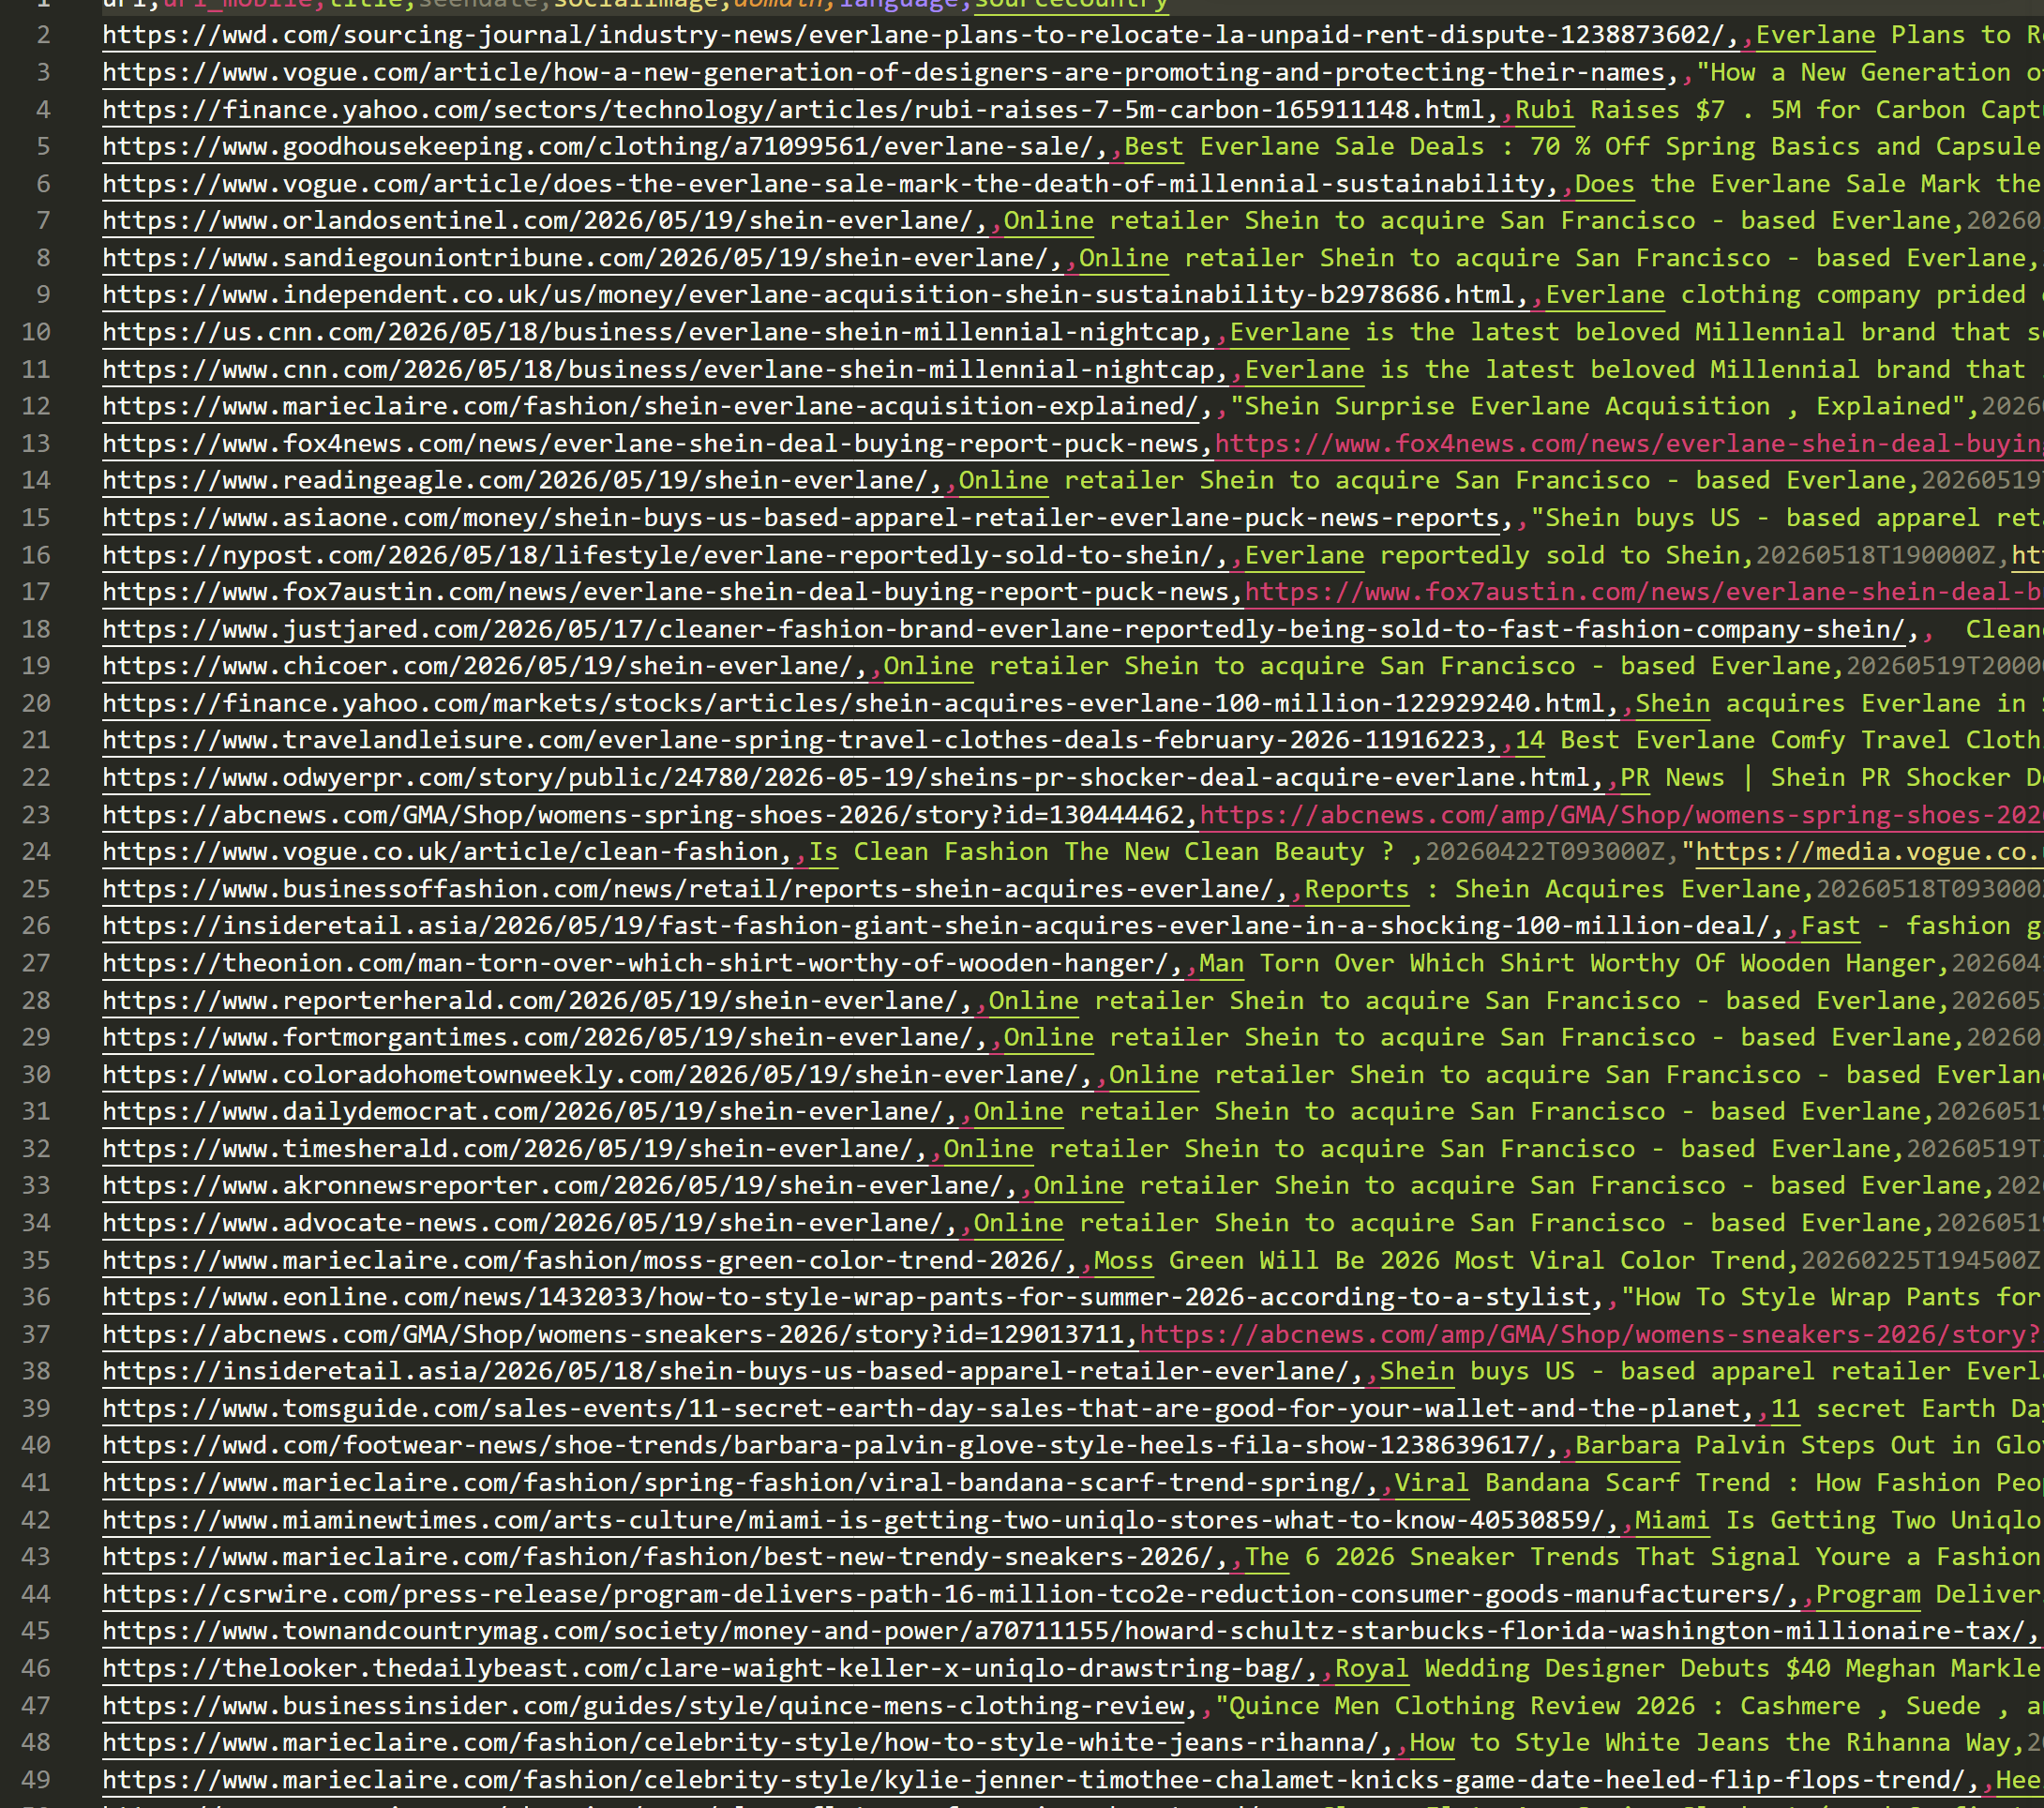
The 100 articles above seem like a nice start, but I can't really trust the validity of the articles scraped in gdelt_news.csv since GDELT does not have reliable date filtering and the rate limits make me suspect that the articles provided are artifacts of old code which do not guarantee that the entire time range is covered. From this point onward, I'm gonna try using GCP's BigQuery instead and parse through their Global Knowledge Graph (GKG) to get article URLs mentioning Everlane within the metadata. Then, I'll fetch the actual article text from these weblinks with newspaper3k and save it to a csv. 

As an aside, one reason why GCP's BigQuery is useful here is that it doesn't have any rate limits since it's historical coverage goes all the way back to 2016. Additionally, we can use SQL to specify my search parameters more reliably than if I were to just use near(), which breaks very easily even when querying with something as simple as "Everlane" for my keyword parameter.

Note for reproducability: Do this before scraping!:
1. You must create a new Google Cloud Project with the BigQuery API enabled
2. Download the Google Cloud CLI installer and run it. 
3. After install, open a new terminal and run: gcloud auth application-default login

I also wanted to describe how I set up my Service Account below so that we wont run into DefaultCredentialsErrors:

4. Within GCP Console, navigate to IAM & Admin -> Service Accts. -> Create Service Account
5. Name it and grant two roles: BigQuery Job User and BigQuery Data Viewer. Click done after adding.
6. Then within the Service Account you just created, navigate to the Keys Tab -> Add Key -> JSON -> download the file
7. Add the file credentials to the top of your code block before initializing your bigquery.Client(project). 

Now, the setup is complete!

In [1]:
import sys
!{sys.executable} -m pip install google-cloud-bigquery db-dtypes

   ---------------------------------------- 0.0/262.3 kB ? eta -:--:--
   ------------------------------- -------- 204.8/262.3 kB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 262.3/262.3 kB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/173.3 kB ? eta -:--:--
   --------------------------------------- 173.3/173.3 kB 10.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/246.1 kB ? eta -:--:--
   ------ --------------------------------- 41.0/246.1 kB ? eta -:--:--
   ------ --------------------------------- 41.0/246.1 kB ? eta -:--:--
   ------ --------------------------------- 41.0/246.1 kB ? eta -:--:--
   ------ --------------------------------- 41.0/246.1 kB ? eta -:--:--
   --------- ----------------------------- 61.4/246.1 kB 252.2 kB/s eta 0:00:01
   ----------------------- -------------- 153.6/246.1 kB 538.9 kB/s eta 0:00:01
   -------------------------------------- 246.1/246.1 kB 719.0 kB/s eta 0:00:00
   ----------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
from google.cloud import bigquery
import pandas as pd

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\micha\Downloads\everlane-analysis-74019e58300f.json"

client = bigquery.Client(project="everlane-analysis")

query = """
SELECT
    CAST(DATE AS STRING) AS date,
    SourceCommonName,
    DocumentIdentifier,
    V2Tone,
    V2Themes,
    AllNames,
    V2Organizations,
    V2Locations
FROM `gdelt-bq.gdeltv2.gkg`
WHERE DATE BETWEEN 20180101000000 AND 20260527235959
  AND (LOWER(AllNames) LIKE '%everlane%'
       OR LOWER(V2Organizations) LIKE '%everlane%')
"""

df_gdelt = client.query(query).to_dataframe()
print(f"{len(df_gdelt)} articles found")
df_gdelt.to_csv("../data/raw/gdelt_historical.csv", index=False)

c:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


1606 articles found


## Looking at our scrape (again)...
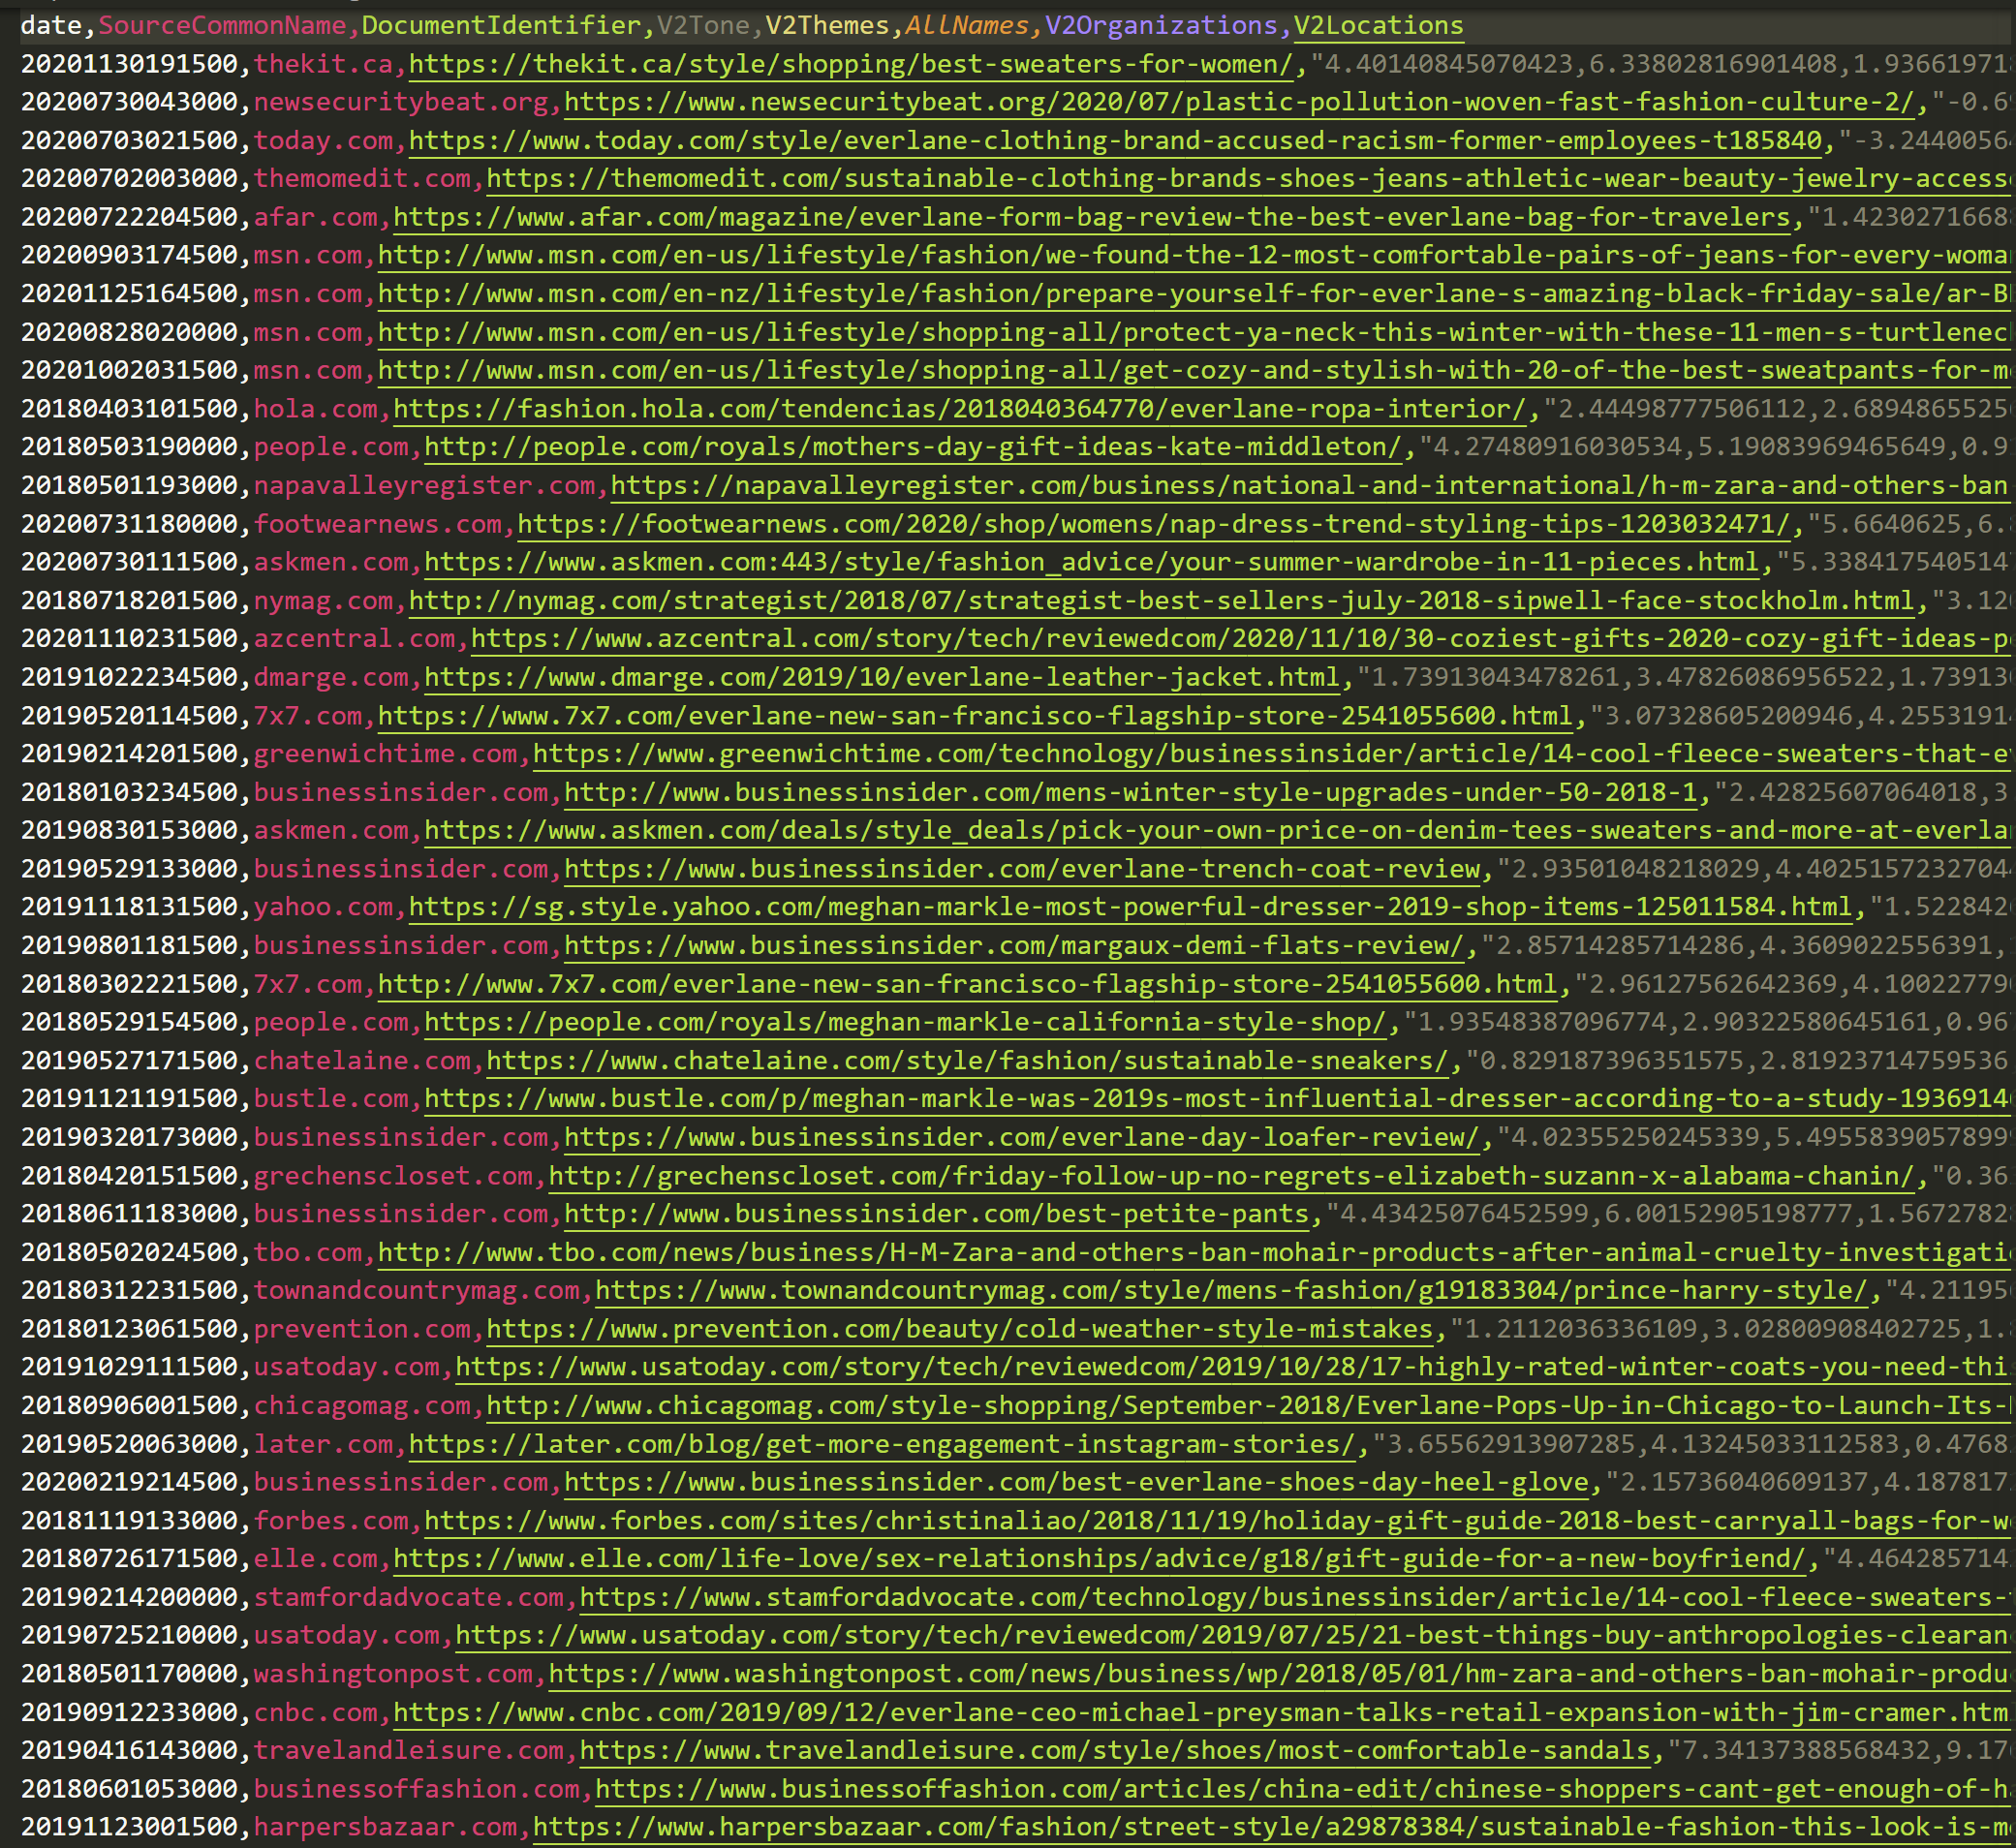

From the raw query, the output news articles don't seem to be really relevant to our brand analysis. I ran this block again before saving the outputs, but the first run provided something to the tune of 1600 articles. We needed to tighten that search query to:
- check for duplicates
- filter by relevance in terms of keyword positioning and first mentions programatically
- filter for consumer-clickbait heuristically

I'm also expanding the search to the last decade for analysis (2016) but admittedly, the selected time period is arbitrarily bound to BigQuery's earliest year of coverage. A quick Google search will tell you that the company was established in 2011, so examining Everlane from its fifth year to its fifteenth year may be a little broad but we can let the data tell us whether or not to expand or shrink this range.

In [13]:
query = """
SELECT
    CAST(DATE AS STRING) AS date,
    SourceCommonName,
    DocumentIdentifier,
    V2Tone,
    V2Themes,
    AllNames,
    V2Organizations,
    V2Locations
FROM `gdelt-bq.gdeltv2.gkg`
WHERE DATE BETWEEN 20160101000000 AND 20260527235959
  AND (
    LOWER(AllNames) LIKE '%everlane%'
    OR LOWER(V2Organizations) LIKE '%everlane%'
    OR LOWER(DocumentIdentifier) LIKE '%everlane%'
  )
"""

df_gdelt = client.query(query).to_dataframe()
df_gdelt = df_gdelt.drop_duplicates("DocumentIdentifier").reset_index(drop=True)

def everlane_position(allnames):
    if pd.isna(allnames):
        return 99999
    for chunk in allnames.split(";"):
        parts = chunk.strip().split(",")
        if len(parts) >= 2 and "everlane" in parts[0].lower():
            try:
                return int(parts[-1])
            except ValueError:
                pass
    return 99999

df_gdelt["everlane_position"] = df_gdelt["AllNames"].apply(everlane_position)

df_gdelt = df_gdelt[
    df_gdelt["DocumentIdentifier"].str.lower().str.contains("everlane") |
    (df_gdelt["everlane_position"] < 2000)
].drop(columns="everlane_position").reset_index(drop=True)

c:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [14]:
print(f"Focused articles saved: {len(df_gdelt)}")
df_gdelt.to_csv("../data/raw/gdelt_historical.csv", index=False)
print("Saved.")

Focused articles saved: 2595
Saved.


In [15]:
exclude_patterns = [
    "sale", "deal", "discount", "promo", "coupon",
    "gift", "best-of", "roundup", "style", "trending",
    "under-100", "under-50", "shopping-list", "hype", 
    "haul", "unboxing", "try-on", "review", "wishlist",
    "launches", "black-friday", "cyber-monday", "gift-guide", 
    "shopping-guide", "obsessed", "best", "best-sellers"  
]

pattern = "|".join(exclude_patterns)
before = len(df_gdelt)
df_gdelt = df_gdelt[
    ~df_gdelt["DocumentIdentifier"].str.lower().str.contains(pattern, na=False)
].reset_index(drop=True)
print(f"Dropped {before - len(df_gdelt)} shopping articles, {len(df_gdelt)} remain")

df_gdelt.to_csv("../data/raw/gdelt_historical.csv", index=False)
print("Saved.")

Dropped 1297 shopping articles, 1298 remain
Saved.


# Onto retrieving text!
Now we can finally get to using newspaper3k to fetch our our text. I'm expecting maybe half of the URL's to actually be read since we might run into 404 errors, paywalls, or timeouts. BeautifulSoup wouldn't be of help here since I would need to get custom selectors for each site's HTML structure and that would take too long to make. In addition to being an even bigger time sink than BS4, Selenium would only help out if there are JS issues, but it still doesn't address the 404 or paywall problem.  

In [17]:
from newspaper import Article
import time

df_gdelt = pd.read_csv("../data/raw/gdelt_historical.csv")
urls = df_gdelt["DocumentIdentifier"].dropna().unique().tolist()
print(f"URLs to fetch: {len(urls)}")

CHECKPOINT = "../data/raw/gdelt_articles_checkpoint.csv"
OUTFILE     = "../data/raw/gdelt_articles.csv"

# Resume from checkpoint if it exists
if os.path.exists(CHECKPOINT):
    done = pd.read_csv(CHECKPOINT)
    done_urls = set(done["url"].tolist())
    results = done.to_dict("records")
    print(f"Resuming — {len(done_urls)} already done, {len(urls) - len(done_urls)} remaining")
else:
    done_urls = set()
    results = []

for i, url in enumerate(urls):
    if url in done_urls:
        continue

    row = {"url": url, "title": None, "text": None, "publish_date": None, "status": None}
    try:
        article = Article(url, request_timeout=10)
        article.download()
        article.parse()
        row.update({
            "title":        article.title,
            "text":         article.text,
            "publish_date": article.publish_date,
            "status":       "ok" if article.text else "empty",
        })
    except Exception as e:
        row["status"] = f"error: {type(e).__name__}"

    results.append(row)
    done_urls.add(url)
    time.sleep(0.5)

    # Save checkpoint every 50 articles
    if len(results) % 50 == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT, index=False)
        ok = sum(1 for r in results if r["status"] == "ok")
        print(f"[{len(results)}/{len(urls)}] fetched — {ok} with text")

URLs to fetch: 1298
[50/1298] fetched — 26 with text
[100/1298] fetched — 59 with text
[150/1298] fetched — 100 with text
[200/1298] fetched — 146 with text
[250/1298] fetched — 181 with text
[300/1298] fetched — 208 with text
[350/1298] fetched — 253 with text
[400/1298] fetched — 295 with text
[450/1298] fetched — 345 with text
[500/1298] fetched — 394 with text
[550/1298] fetched — 443 with text
[600/1298] fetched — 492 with text
[650/1298] fetched — 529 with text
[700/1298] fetched — 555 with text
[750/1298] fetched — 592 with text
[800/1298] fetched — 626 with text
[850/1298] fetched — 675 with text
[900/1298] fetched — 723 with text
[950/1298] fetched — 772 with text
[1000/1298] fetched — 803 with text
[1050/1298] fetched — 816 with text
[1100/1298] fetched — 848 with text
[1150/1298] fetched — 888 with text
[1200/1298] fetched — 928 with text
[1250/1298] fetched — 974 with text


Only took a calm 36 minutes to run, but we ended up preserving a good majority (1015 valid articles of text saved to a csv), a pretty good haul if you ask me. Now, we just have to remove articles that error out or are empty from our csv to drop any misleading signals and then move onto our analysis.

In [18]:
# Final save
df_articles = pd.DataFrame(results)
df_articles.to_csv(OUTFILE, index=False)
if os.path.exists(CHECKPOINT):
    os.remove(CHECKPOINT)

ok = (df_articles["status"] == "ok").sum()
print(f"\nDone: {ok}/{len(df_articles)} articles with text saved to {OUTFILE}")
df_articles["status"].value_counts()


Done: 1015/1298 articles with text saved to ../data/raw/gdelt_articles.csv


status
ok                         1015
error: ArticleException     258
empty                        25
Name: count, dtype: int64

In [ ]:
df_articles = pd.read_csv("../data/raw/gdelt_articles.csv")

df_usable = df_articles[df_articles["status"] == "ok"].reset_index(drop=True)
print(f"Kept {len(df_usable)} usable articles (dropped {len(df_articles) - len(df_usable)} ArticleException + empty)")

df_usable.to_csv("../data/raw/gdelt_articles_usable.csv", index=False)
print("Saved to gdelt_articles_usable.csv")

Kept 1015 usable articles (dropped 283 ArticleException + empty)
Saved to gdelt_articles_usable.csv


# End of our Data Scraping! 🎉🎉🎉

## Let's put this notebook into review. 

The raw dataset spans three sources:
- 4,600 Reddit posts and 12,400 comments covering consumer sentiment,
- 28,400 lines from over 1,000 news articles capturing media coverage,
- And nearly 1,400 lines scraped directly from Everlane's website. 

Together, these form a multi-perspective corpus of ~47,000 lines for preliminary analysis. Keep in mind, this is only a current snapshot as of 5/27/2026. The raw data files are expected to expand (especially for Everlane's website) as we go through the data flywheel should we decide to examine different snapshots in time for the brand's point-of-sale.
- 1,400 lines sound measly relative to the corpus of our other two sources but in a sense, this is our official baseline signal that we can measure against, so it carries more interpretive weight by design. 
- Mission statements, marketing language, brand-controlled communications-- these are all things that we expect to change drastically when looking through the past-UX decisions on Everlane's website throughout 2016-2026. 
